In [ ]:
# TASK 01: House Price Prediction using Linear Regression (California Housing Dataset)
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import the dataset and modeling tools from sklearn
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Magic command to make plots show up in the notebook
%matplotlib inline

In [ ]:
# 1. Load the REAL California Housing Dataset
print("1. Loading the California Housing dataset...")
# Load the dataset as a "Bunch" object (like a dictionary)
california = fetch_california_housing()

# Let's see what's inside this dataset
print("Dataset keys:", california.keys())
print("Feature names:", california.feature_names)
print("Dataset description:\n", california.DESCR[:500], "...") # Shows first 500 chars of description
print("\n")

1. Loading the California Housing dataset...
Dataset keys: dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Dataset description:
 .. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group popu ...




In [ ]:
# Create a Pandas DataFrame for easier manipulation and viewing
df = pd.DataFrame(california.data, columns=california.feature_names)
# The target (house value) is in a separate attribute, so we add it to the DataFrame
df['Price'] = california.target * 100000  # Convert from $100,000 units to actual dollar amounts

print("First 5 rows of the California Housing dataset:")
print(df.head())
print("\n")

First 5 rows of the California Housing dataset:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude     Price  
0    -122.23  452600.0  
1    -122.22  358500.0  
2    -122.24  352100.0  
3    -122.25  341300.0  
4    -122.25  342200.0  




In [ ]:
# 2. Explore the Data
print("2. Exploring the dataset...")
# Check the first few rows
print("First 5 rows:")
print(df.head())
print("\n")

# Get basic information (number of rows, columns, data types)
print("Dataset info:")
print(df.info())
print("\n")

# Get statistical summary (mean, std, min, max etc.)
print("Statistical summary:")
print(df.describe())
print("\n")

2. Exploring the dataset...
First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude     Price  
0    -122.23  452600.0  
1    -122.22  358500.0  
2    -122.24  352100.0  
3    -122.25  341300.0  
4    -122.25  342200.0  


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640

3. Creating plots to understand the data...


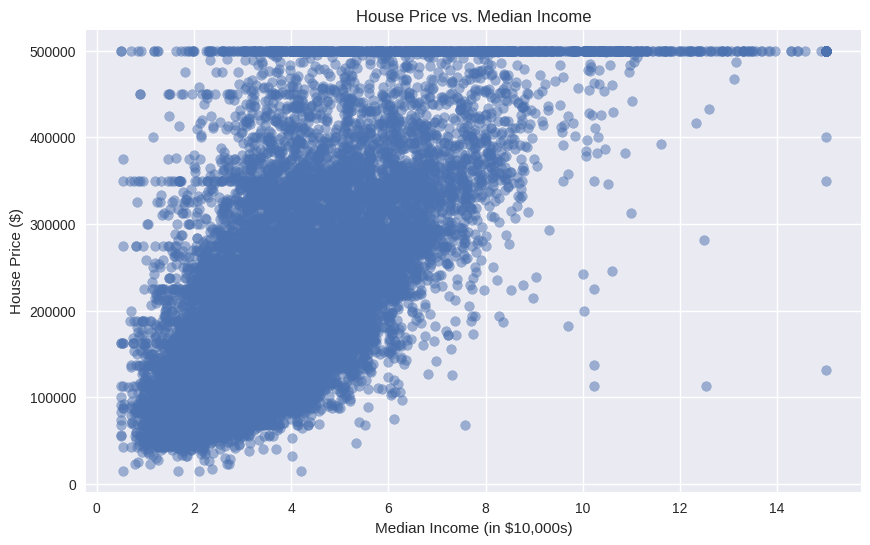

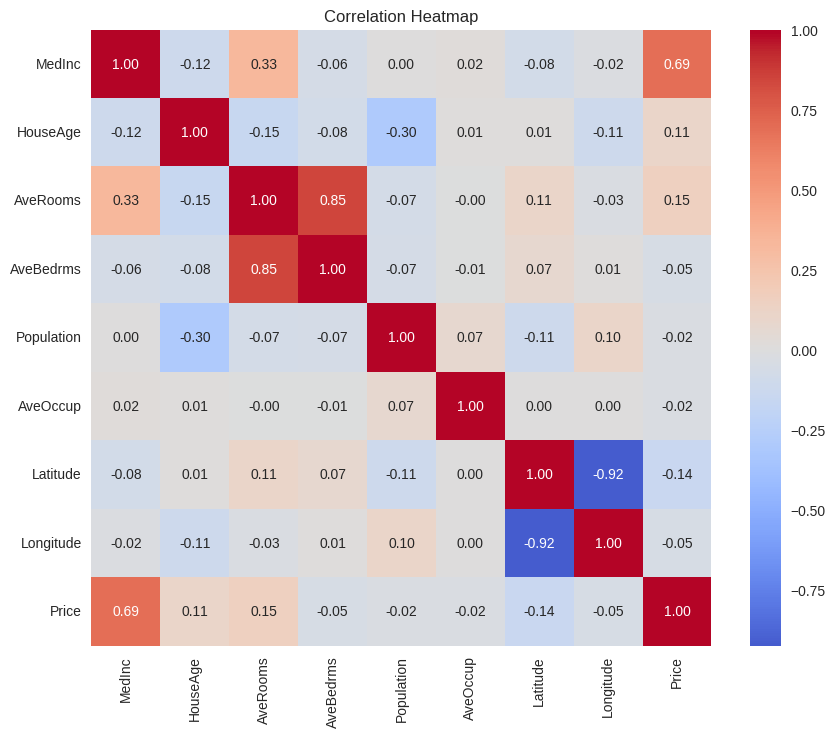

In [ ]:
# 3. Visualize the Relationships (This is important!)
print("3. Creating plots to understand the data...")
# Set a nicer style for our plots
plt.style.use('seaborn-v0_8')

# See how the most important feature (MedInc) correlates with Price
plt.figure(figsize=(10, 6))
plt.scatter(df['MedInc'], df['Price'], alpha=0.5) # alpha makes points semi-transparent
plt.title('House Price vs. Median Income')
plt.xlabel('Median Income (in $10,000s)')
plt.ylabel('House Price ($)')
plt.show()

# A heatmap of correlation coefficients to see all relationships at once
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()
print("\n")


In [ ]:
# 4. Prepare the Data for the Model
print("4. Preparing data for training...")
# X = The features we use to predict (Independent Variables)
# We'll use all available features for this model
X = df.drop('Price', axis=1)
# y = The thing we want to predict (Dependent Variable)
y = df['Price']

print("Features (X):")
print(X.head())
print("\nTarget (y):")
print(y.head())
print("\n")

# Split the data into training and testing sets
# We train the model on 80% of the data and test it on the remaining 20%.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print("\n")


4. Preparing data for training...
Features (X):
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Target (y):
0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: Price, dtype: float64


Training set size: (16512, 8)
Testing set size: (4128, 8)




In [ ]:
# 5. Create and Train the Model
print("5. Training the Linear Regression model...")
# Create an instance of the LinearRegression model
model = LinearRegression()

# Train the model using the training data
# This is where the magic happens - the model learns the relationships!
model.fit(X_train, y_train)
print("Model training complete!")
print("\n")

5. Training the Linear Regression model...
Model training complete!




In [ ]:
# 6. Make Predictions and Evaluate the Model
print("6. Making predictions and evaluating the model...")
# Let's see what the model predicts for the houses in our test set
y_pred = model.predict(X_test)

# Compare the predictions with the actual prices for the first 10 houses
results_df = pd.DataFrame({'Actual Price': y_test[:10], 'Predicted Price': y_pred[:10], 'Difference': y_test[:10] - y_pred[:10]})
print("Comparison on first 10 Test Data points:")
print(results_df)
print("... (and more)")
print("\n")

# Calculate evaluation metrics for the entire test set
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error is more interpretable
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Mean Squared Error (MSE): ${mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared Score (R²): {r2:.4f}")
print("\n")

6. Making predictions and evaluating the model...
Comparison on first 10 Test Data points:
       Actual Price  Predicted Price     Difference
20046       47700.0     71912.284160  -24212.284160
3024        45800.0    176401.657066 -130601.657066
15663      500001.0    270965.883343  229035.116657
20484      218600.0    283892.593018  -65292.593018
9814       278000.0    260465.725181   17534.274819
13311      158700.0    201175.367325  -42475.367325
7113       198200.0    264550.004938  -66350.004938
7668       157500.0    216875.532129  -59375.532129
18246      340000.0    274074.644114   65925.355886
5723       446600.0    391561.472503   55038.527497
... (and more)


Model Evaluation Metrics:
Mean Absolute Error (MAE): $53,320.01
Mean Squared Error (MSE): $5,558,915,986.95
Root Mean Squared Error (RMSE): $74,558.14
R-squared Score (R²): 0.5758




In [ ]:
# 7. Understanding the Model
print("7. Understanding the model coefficients...")
# The model has learned a formula: Price = intercept + (coef1 * MedInc) + (coef2 * HouseAge) + ...
print("Model Coefficients:")
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient ($)': model.coef_})
print(coefficients)
print(f"\nIntercept: ${model.intercept_:.2f}")
print("\nThis means, all else being equal:")
print(f"- A 1-unit increase in MedInc (=$10,000) adds ${model.coef_[0]:.2f} to the price.")
print(f"- A 1-year increase in House Age adds ${model.coef_[1]:.2f} to the price.")
print(f"- Having 1 more room (AveRooms) adds ${model.coef_[2]:.2f} to the price.")
print("\n")

7. Understanding the model coefficients...
Model Coefficients:
      Feature  Coefficient ($)
0      MedInc     44867.490967
1    HouseAge       972.425752
2    AveRooms    -12332.334283
3   AveBedrms     78314.490679
4  Population        -0.202962
5    AveOccup      -352.631849
6    Latitude    -41979.248659
7   Longitude    -43370.806496

Intercept: $-3702327.77

This means, all else being equal:
- A 1-unit increase in MedInc (=$10,000) adds $44867.49 to the price.
- A 1-year increase in House Age adds $972.43 to the price.
- Having 1 more room (AveRooms) adds $-12332.33 to the price.




In [ ]:
# 8.Make a prediction for a new house
print("8. Predicting the price of a new house in California...")
# Let's create a sample house with values close to the dataset's averages
# [MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude]
new_house = [[3.5, 30, 5.5, 1.1, 1500, 3.0, 35.5, -120.0]]
predicted_price = model.predict(new_house)
print(f"Predicted price for the sample house: ${predicted_price[0]:,.2f}")

8. Predicting the price of a new house in California...
Predicted price for the sample house: $215,070.44


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
